<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_5_1_Trees_Data_and_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Trees: The Foundation of Ensembles

Author: Brad Sheese

---

## Introduction
In this notebook, we move from the probability-based logic of Logistic Regression to the "flowchart" logic of **Decision Trees**. Decision trees are highly interpretable, making them the most easily explainable machine learning models for non-technical audiences.

However, we will also see their primary weakness: **overfitting**. This notebook will serve as our to building building high-performance ensembles like Random Forests and Boosting models later in this series.

### Learning Objectives
By the end of this notebook, you will be able to:
1. **Load and Explore** the Wisconsin Breast Cancer (Diagnostic) dataset.
2. **Implement** a Decision Tree classifier using `scikit-learn`.
3. **Visualize** the model's decision-making process with a tree diagram.
4. **Evaluate** the impact of tree depth on model accuracy and overfitting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set style
sns.set_context("talk")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data Preparation: Wisconsin Breast Cancer Dataset

We are working with measurements taken from digitized images of a fine needle aspirate (FNA) of a breast mass. These describe characteristics of the cell nuclei present in the image.

### Data Details
- Name: Wisconsin Diagnostic Breast Cancer (WDBC)
- Alternative Name: Breast Cancer Wisconsin (Diagnostic) Data Set
- Source: UCI Machine Learning Repository
- Size: 569 samples
- Features: 30 real-valued features computed from digitized images of fine needle aspirate (FNA) of breast masses
- Feature Groups: For each of 10 morphological characteristics, three values are computed:
  - Mean
  - Standard error
  - "Worst" (mean of the three largest values)
- The 10 base features:
  1. Radius (mean of distances from center to perimeter points)
  2. Texture (standard deviation of gray-scale values)
  3. Perimeter
  4. Area
  5. Smoothness (local variation in radius lengths)
  6. Compactness (perimeter²/area - 1.0)
  7. Concavity (severity of concave portions of contour)
  8. Concave points (number of concave portions of contour)
  9. Symmetry
  10. Fractal dimension ("coastline approximation" - 1)
- Total Features: 30 (3 feature groups X 10 base features)
- Usage: Features describe characteristics of cell nuclei present in the image


**Goal**: Predict whether a mass is **Malignant** (1) or **Benign** (0).

In [2]:
# Load the dataset
data = load_breast_cancer(as_frame=True)
df = data.frame

print(f"Dataset Shape: {df.shape}")
print(f"Target Distribution:\n{df['target'].value_counts(normalize=True)}")
df.head()

Dataset Shape: (569, 31)
Target Distribution:
target
1    0.627417
0    0.372583
Name: proportion, dtype: float64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### Exploratory Data Analysis

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

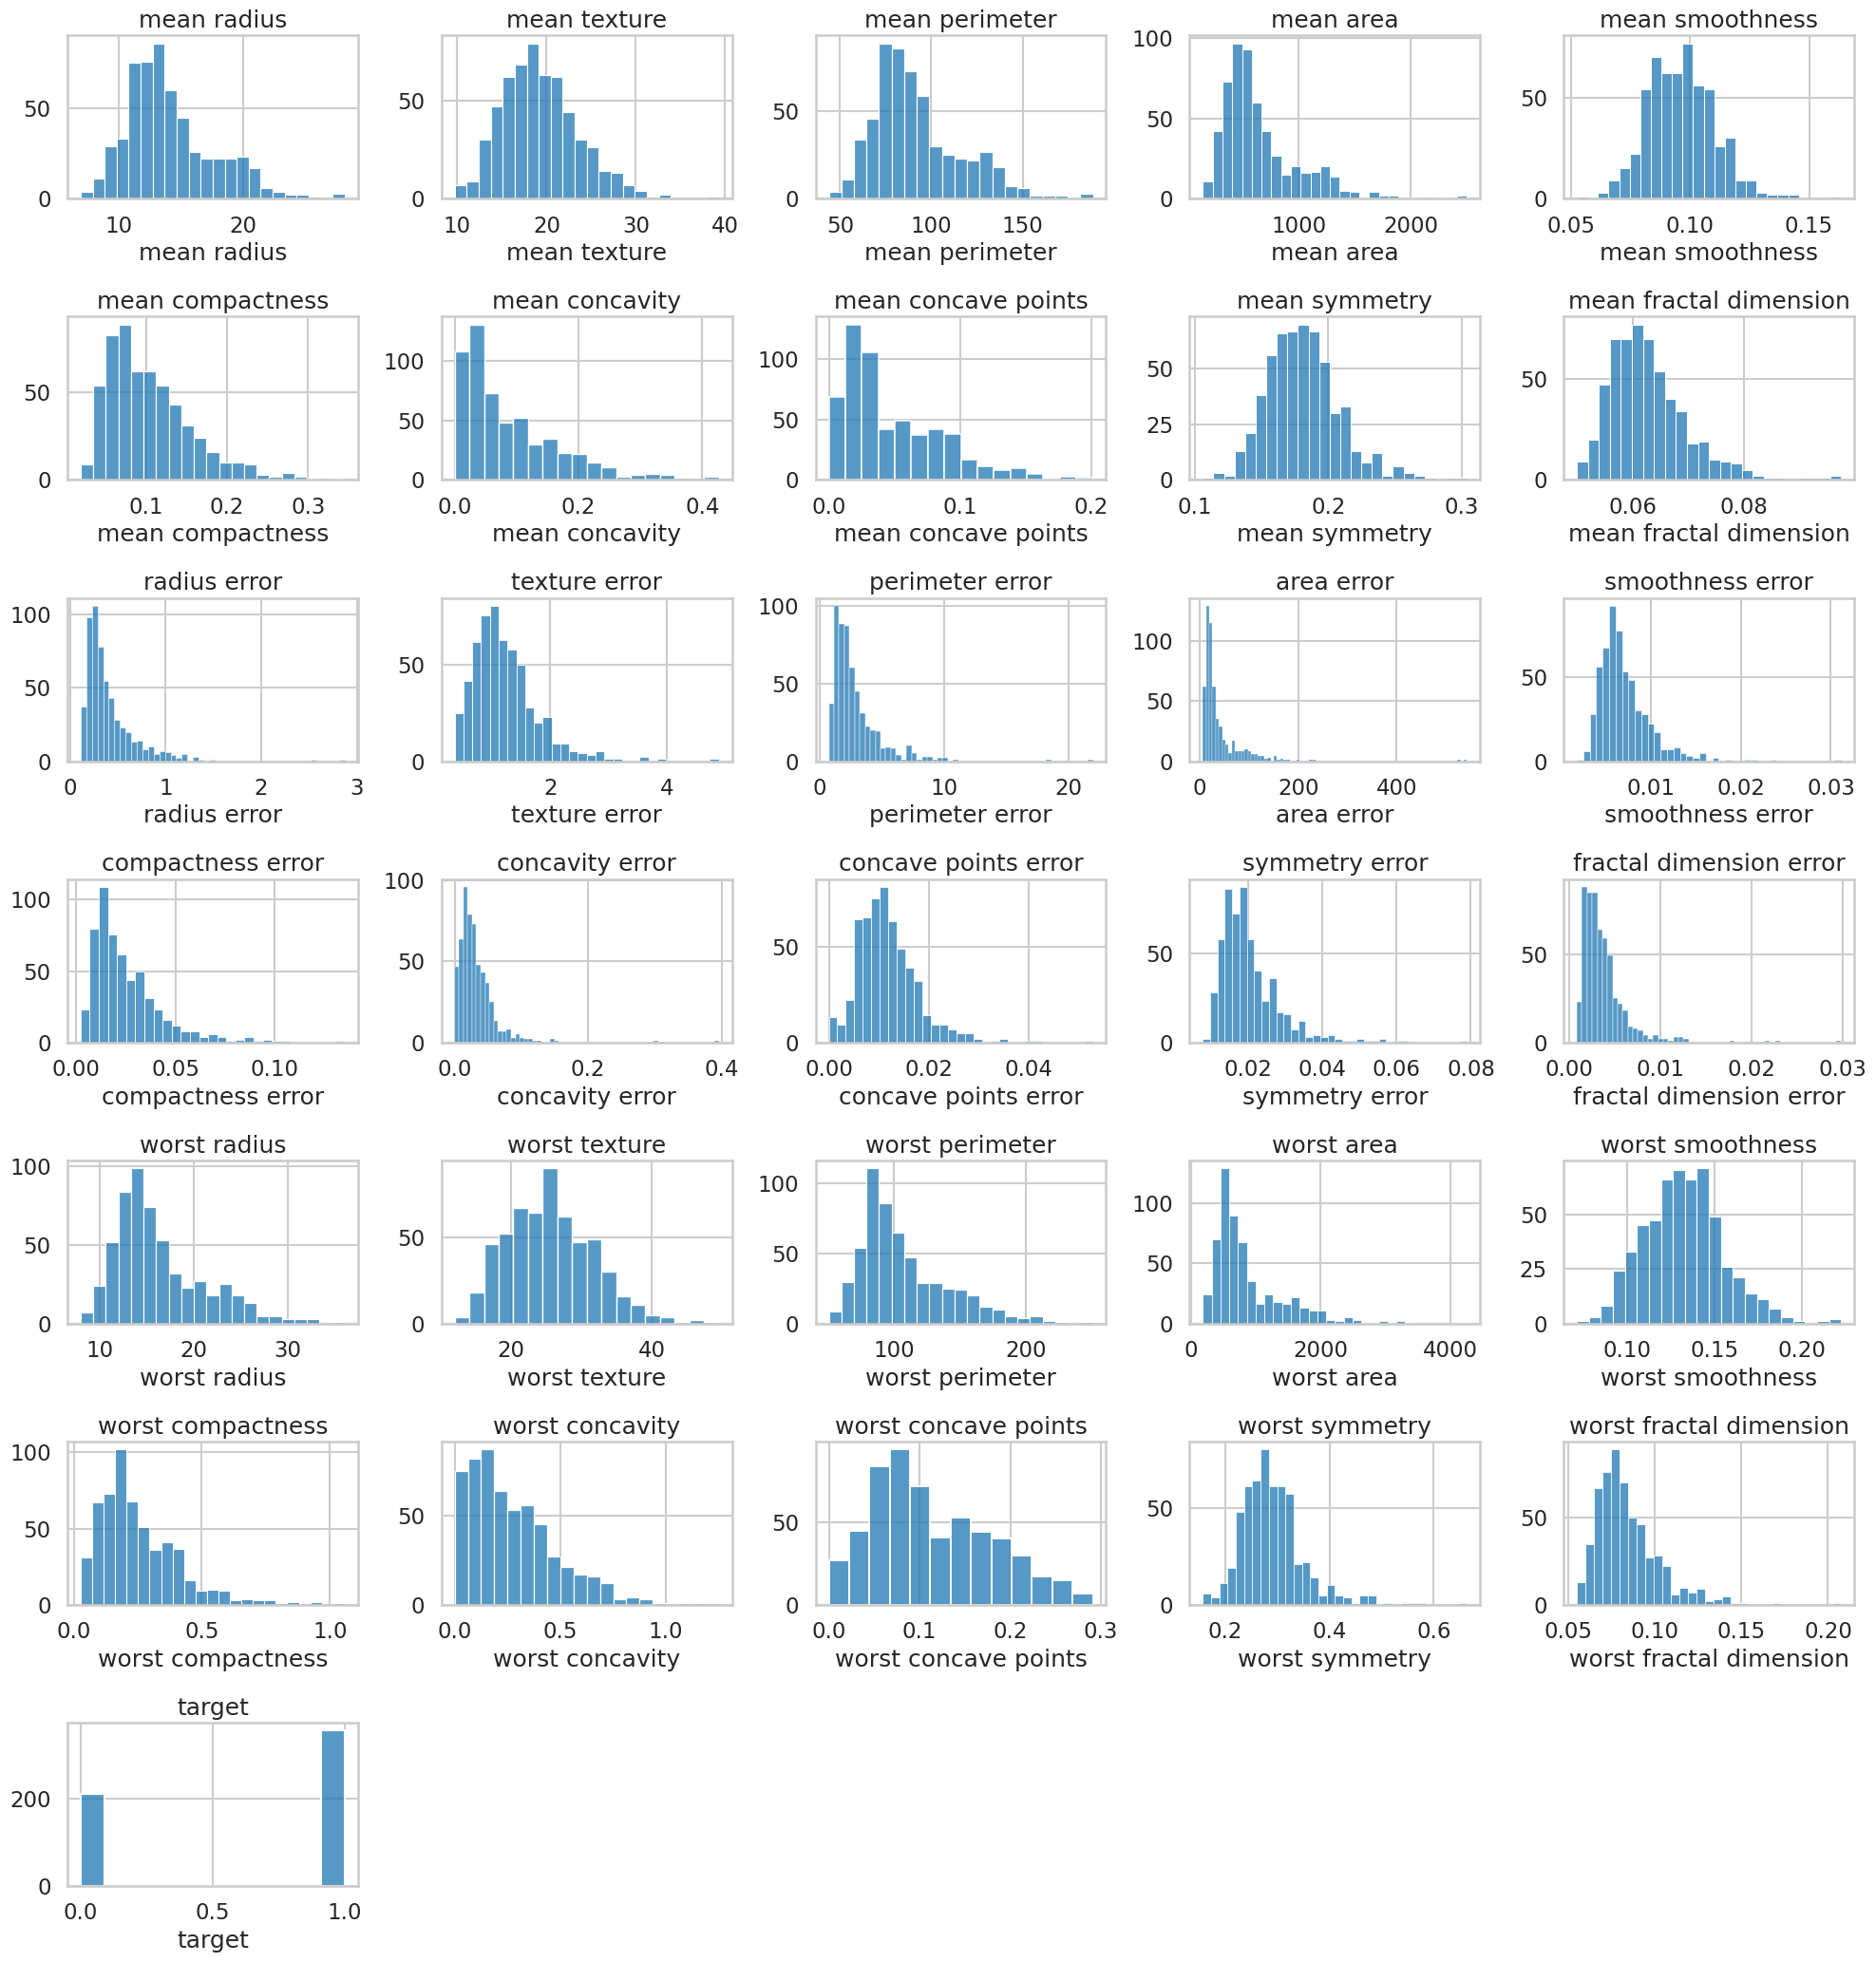

In [10]:
# let's visualize our distributions
n_cols = 5
n_features = len(df.columns)
n_rows = (n_features + n_cols - 1) // n_cols # Calculate number of rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(df.columns):
    sns.histplot(df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel('') # Remove y-label to avoid clutter

# Turn off any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# this is very clean data...
# there's a lot of skew, but these distributions are
# better than many of the datasets we've been dealing with.
# Notably trees don't care about skew. So we don't need to worry about
# correction.

### Visualizing a Split
Decision trees find the best feature and "split point" to divide the data. Let's look at one feature, `mean concave points`, and see how it differs between Malignant and Benign tumors.

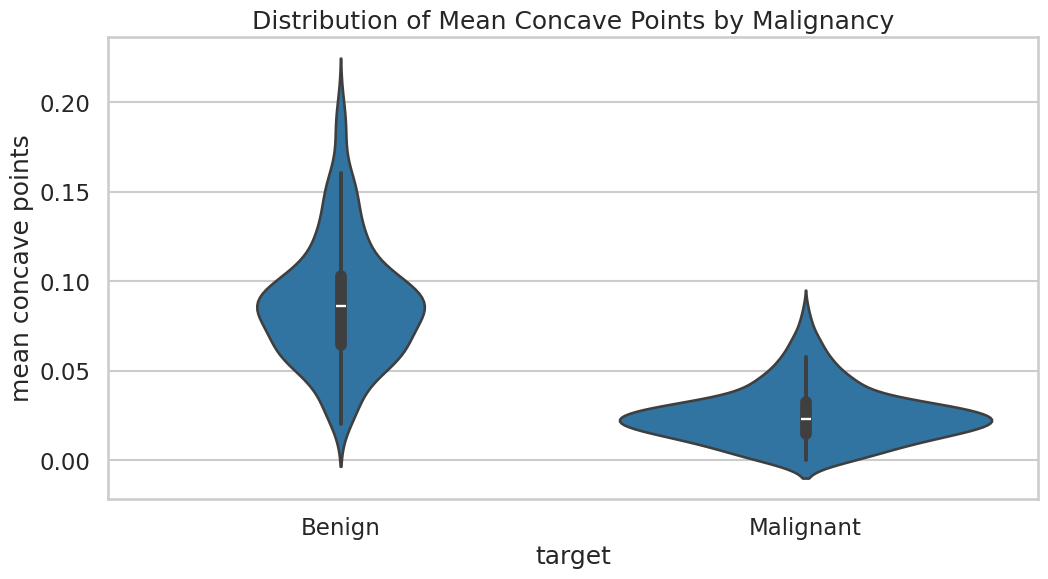

In [3]:
sns.violinplot(x='target', y='mean concave points', data=df)
plt.title("Distribution of Mean Concave Points by Malignancy")
plt.xticks([0, 1], ['Benign', 'Malignant'])
plt.show()

This shows good differentiation. In fact, the tree models will, by themselves, identify this as a good starting point because of the clear differentiation you see here.

It's worth examining the other features in the same way to see they are not so good at differentiating.

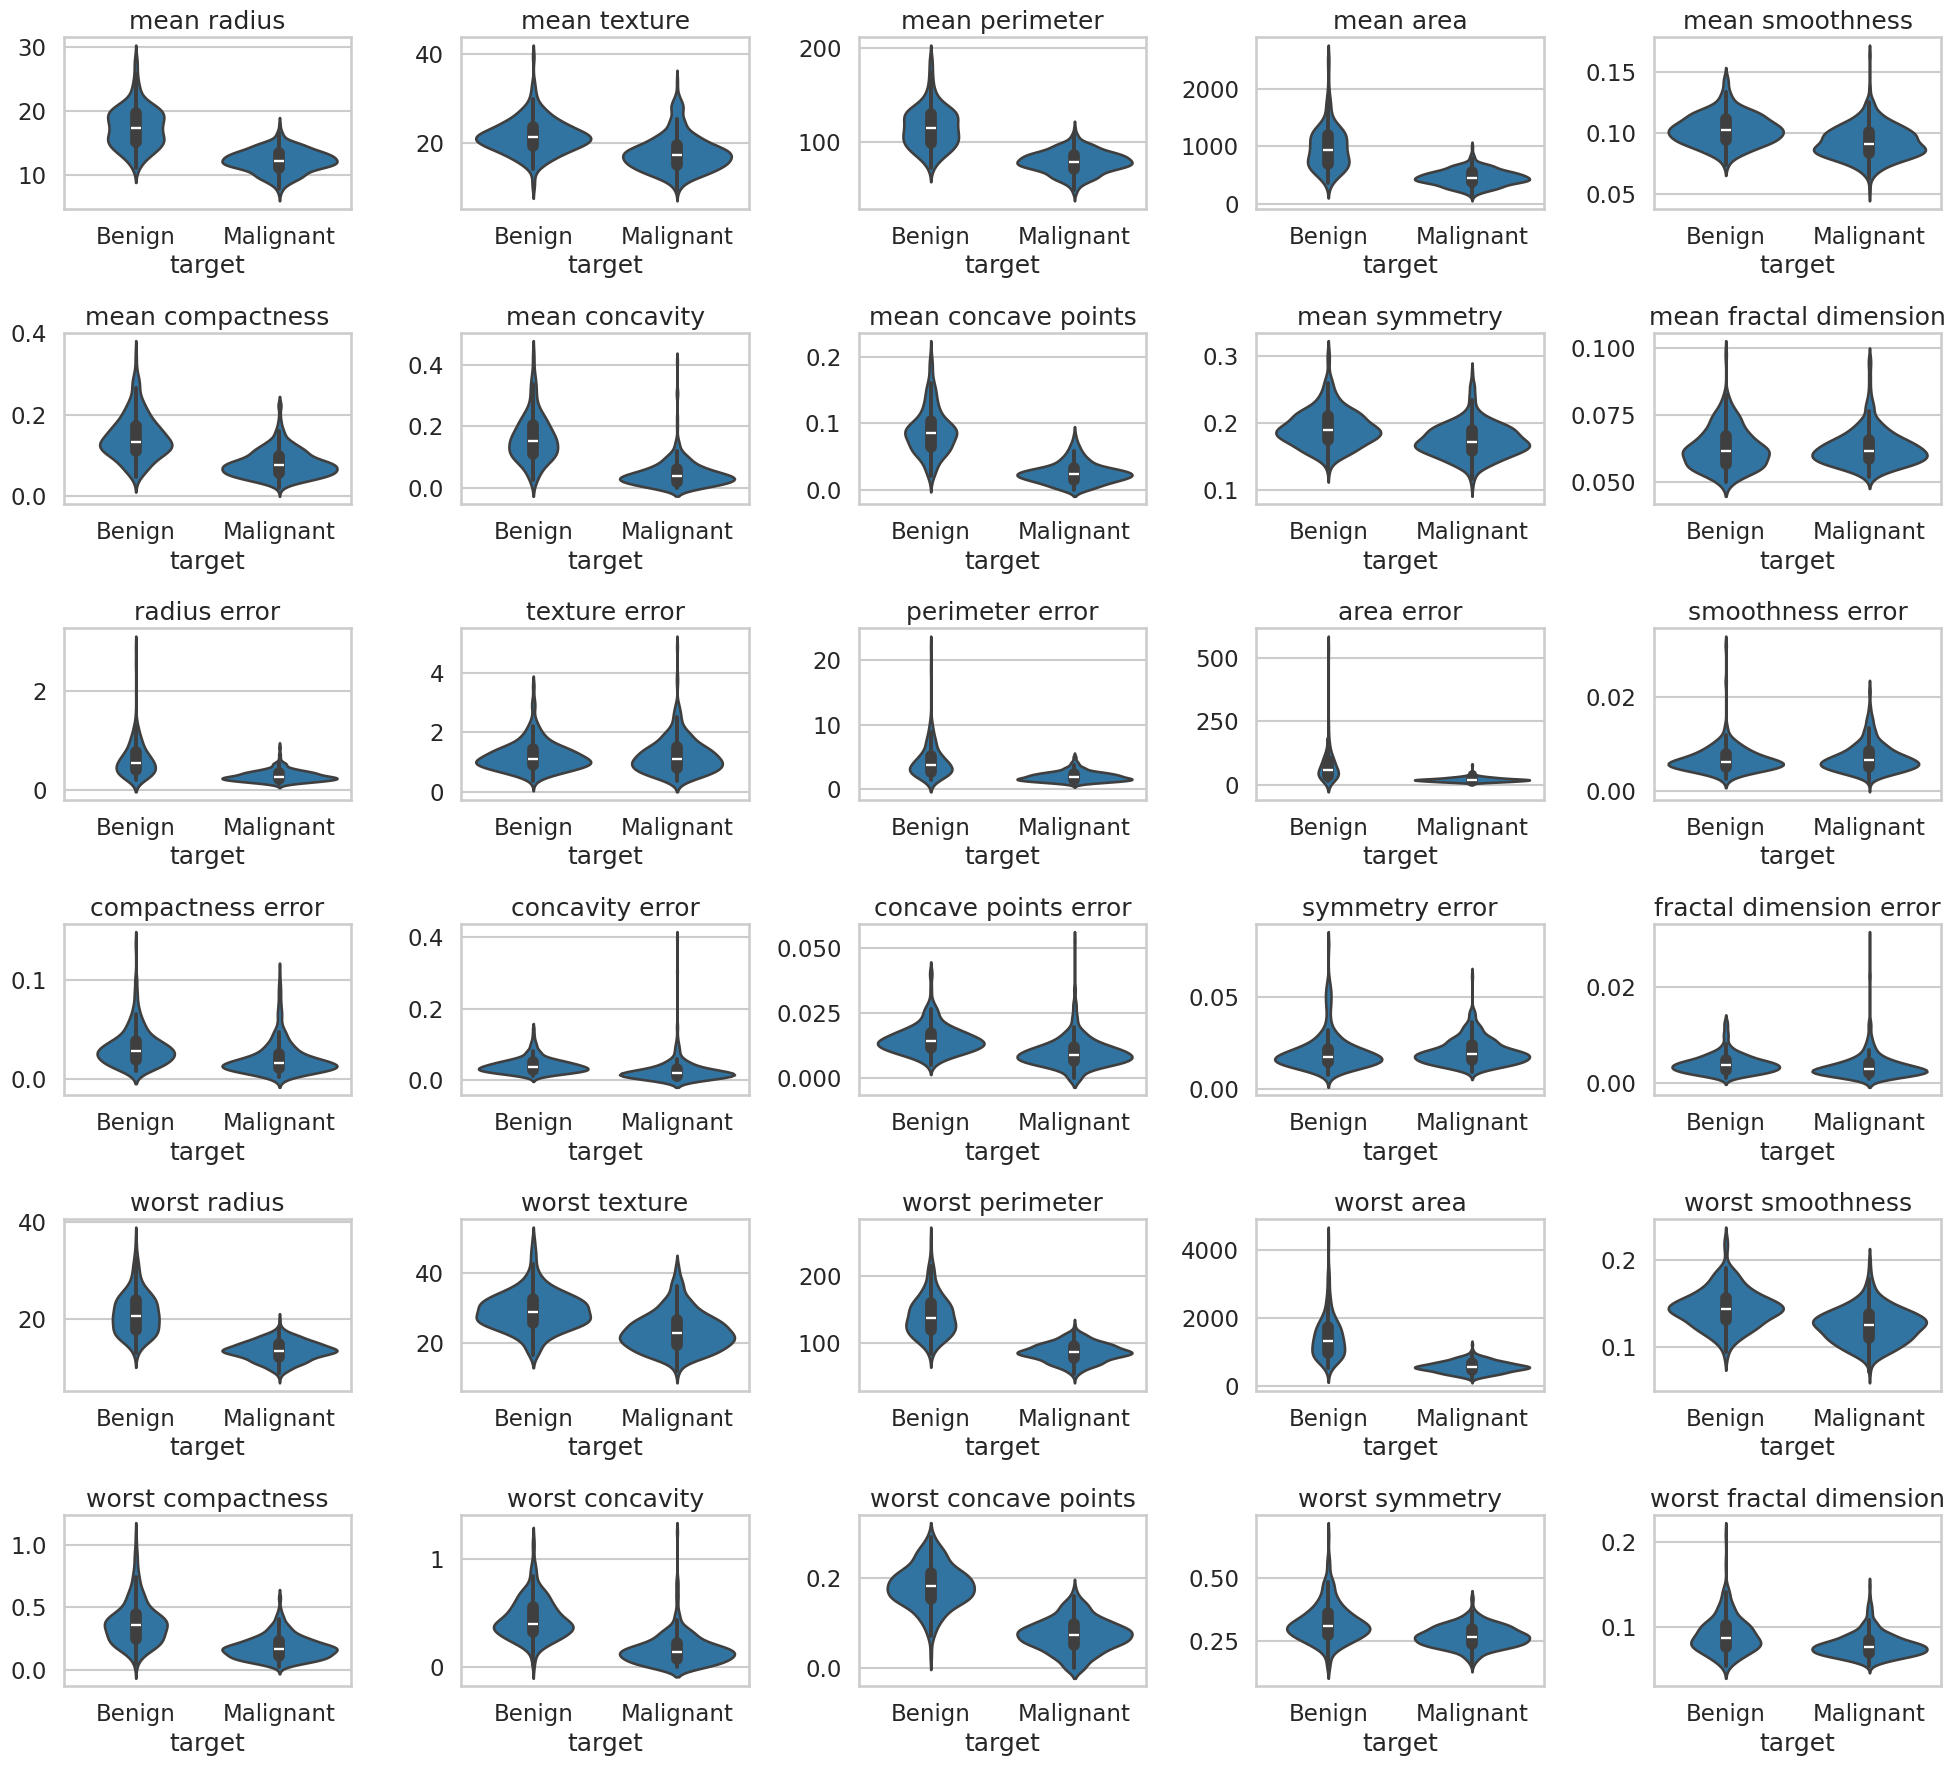

In [14]:
n_cols = 5
n_features = len(df.columns[:-1]) # Exclude 'target'
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(df.columns[:-1]):
    sns.violinplot(x='target', y=col, data=df, ax=axes[i])
    axes[i].set_title(f"{col}")
    axes[i].set_xticks([0, 1], ['Benign', 'Malignant'])
    axes[i].set_ylabel('') # Remove y-label to avoid clutter

# Turn off any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Train/Test Split
To evaluate how our model will perform on brand-new data, we must split our data into training and testing sets.

In [4]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 398
Testing set size: 171


---
## 2. The Building Block: A Single Decision Tree

A decision tree finds a specific feature and threshold to split the data. For example: "If `mean concave points` > 0.05, go left; otherwise, go right."

### Growing the Tree
We use `DecisionTreeClassifier`. We will start by limiting the depth of the tree to `max_depth=3` to keep it interpretable.

In [5]:
# Initialize and fit the model
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

### Visualizing the Logic
The most powerful feature of a decision tree is that we can literally look at its decision-making process.

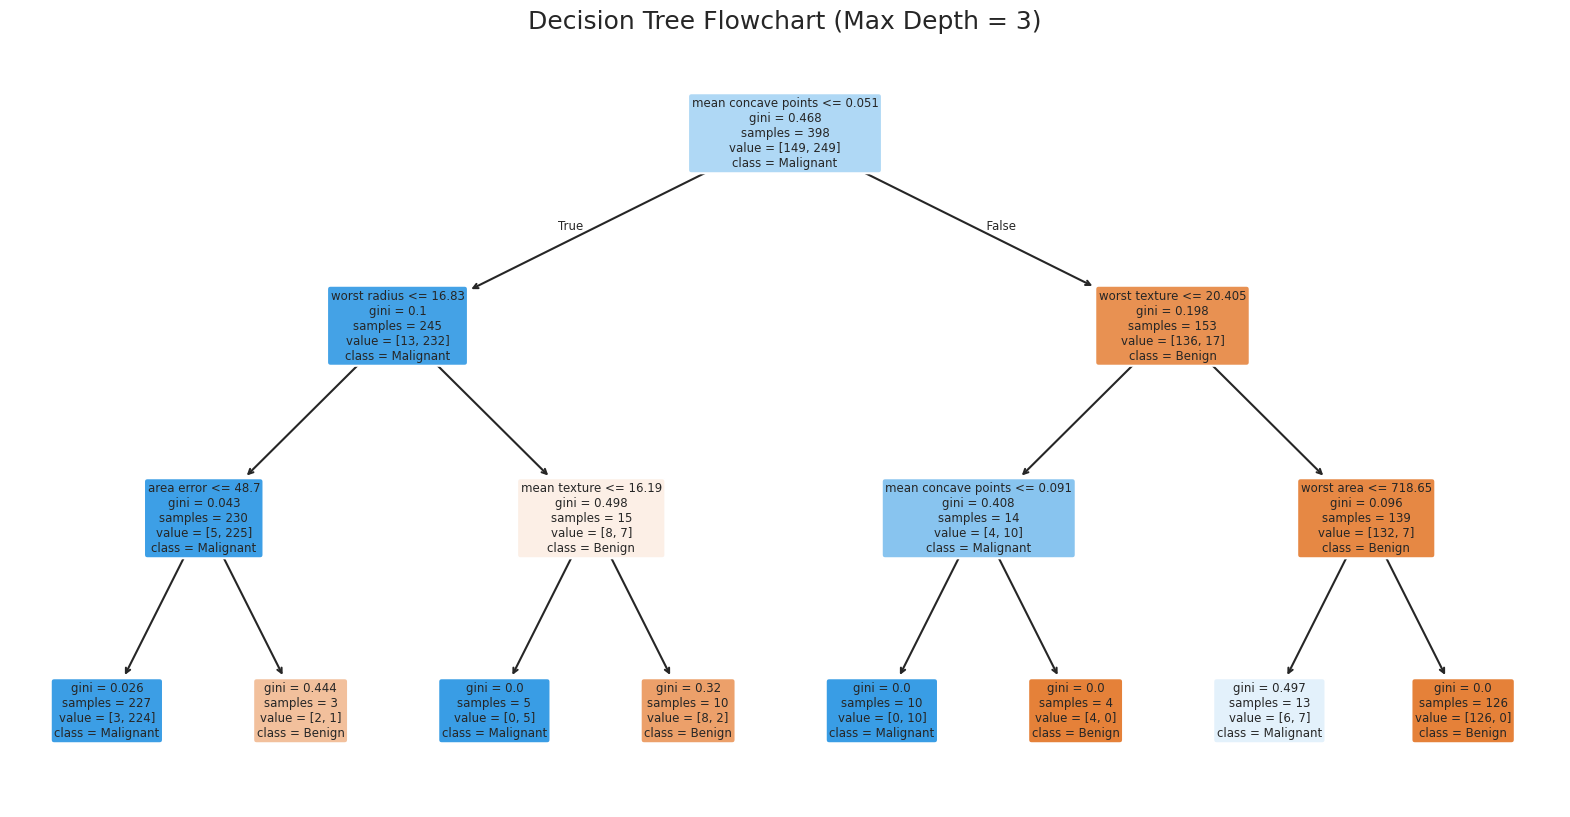

In [6]:
plt.figure(figsize=(20, 10))
plot_tree(clf,
          feature_names=data.feature_names,
          class_names=['Benign', 'Malignant'],
          filled=True,
          rounded=True)
plt.title("Decision Tree Flowchart (Max Depth = 3)")
plt.show()

### How to Read the Tree:
1. **Gini**: A measure of "purity." A Gini of 0.0 means every mass in that node is the same class (perfectly pure).
2. **Samples**: How many mass mass masses are in that node.
3. **Value**: The count of [Benign, Malignant] samples in that node.
4. **Color**: The darker the color, the more "pure" the node is for that class.

---
## 3. The Overfitting Problem

If we don't limit the depth, the tree will keep splitting until every single node is pure. While this looks great on the training data, it often fails on the testing data because the model has "memorized" the noise in the training set.

TO DO: THis needs expansion.

In [7]:
# Full (Overfitted) Tree
full_clf = DecisionTreeClassifier(random_state=42)
full_clf.fit(X_train, y_train)

# Predictions
limited_train_acc = accuracy_score(y_train, clf.predict(X_train))
limited_test_acc = accuracy_score(y_test, clf.predict(X_test))

full_train_acc = accuracy_score(y_train, full_clf.predict(X_train))
full_test_acc = accuracy_score(y_test, full_clf.predict(X_test))

print(f"Limited Tree (Depth 3): Training Acc = {limited_train_acc:.3f}, Test Acc = {limited_test_acc:.3f}")
print(f"Full Tree (No Limit): Training Acc = {full_train_acc:.3f}, Test Acc = {full_test_acc:.3f}")

Limited Tree (Depth 3): Training Acc = 0.970, Test Acc = 0.965
Full Tree (No Limit): Training Acc = 1.000, Test Acc = 0.942


### Discussion: The Complexity Tradeoff
Notice that the "Full Tree" might reach **100% accuracy** on the training data. However, the testing accuracy is often lower than the limited tree. This gap between training and testing performance is the hallmark of **Overfitting**.

In the next notebook, we will learn how to use **Bagging** and **Random Forests** to harness the power of deep trees without suffering from this instability.